In [1]:
#                  Numba
#                    │
#        ┌───────────┼───────────┐
#        ▼           ▼           ▼
#     nogil       prange       LLVM
#        │           │           │
#        ▼           ▼           ▼
#  解除 GIL     CPU多核并行     SIMD优化

In [61]:
from numba import njit, jit, prange
from numpy import arange

import pandas as pd
import numpy as np
import numexpr as ne
import threading
import multiprocessing
import time

from pylab import imshow, jet, show, ion, subplots
from ipywidgets import interact

In [3]:
# jit decorator tells Numba to compile this function.
# The argument types will be inferred by Numba when function is called.

@jit
def sum2d(arr):
    M, N = arr.shape
    result = 0.0
    for i in range(M):
        for j in range(N):
            result += arr[i, j]
    return result

a = arange(9).reshape(3, 3)
print(f'Sum2D: \t\t{sum2d(a)}')
print(f'Numpy sum: \t{a.sum()}')

Sum2D: 		36.0
Numpy sum: 	36


In [4]:
x = {'a': [1, 2, 3], 'b': [20, 30, 40]}

def use_pandas(a):
    df = pd.DataFrame.from_dict(a)
    df += 1
    return df.cov()

@jit(forceobj=True) # Need to use object mode, try and compile loops!
def use_pandas_jit_obj(a): # Function will not benefit from Numba jit
    df = pd.DataFrame.from_dict(a) # Numba doesn't know about pd.DataFrame
    df += 1 # Numba doesn't understand what this is
    return df.cov() # or this!

use_pandas_jit_obj(x)

%timeit use_pandas(x)
%timeit use_pandas_jit_obj(x)

420 μs ± 4.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
566 μs ± 12.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [5]:
@jit(nopython=True, nogil=True)
def worker_nogil(arr1, arr2, arr3, chunk):
    """The thread worker."""
    for index in chunk:
        arr3[index] = arr1[index] + arr2[index]

def worker(arr1, arr2, arr3, chunk):
    """The thread worker."""
    for index in chunk:
        arr3[index] = arr1[index] + arr2[index]

nthreads = multiprocessing.cpu_count()
n = 1000000
a = np.random.randn(n)
b = np.random.randn(n)
c = np.empty(n, dtype='float64')

def run_with_n_threads(chunks, nthreads, worker):
    all_threads = []
    for chunk in chunks:
        thread = threading.Thread(target=worker, args=(a, b, c, chunk))
        all_threads.append(thread)
    for thread in all_threads:
        thread.start()
    for thread in all_threads:
        thread.join()

chunks = np.array_split(range(n), 1)
print("With GIL")
%timeit run_with_n_threads(chunks, 1, worker)
print("Without GIL")
%timeit run_with_n_threads(chunks, 1, worker_nogil)

chunks = np.array_split(range(n), 2)
print("With GIL")
%timeit run_with_n_threads(chunks,2, worker)
print("Without GIL")
%timeit run_with_n_threads(chunks,2, worker_nogil)

With GIL
486 ms ± 4.59 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Without GIL
2.21 ms ± 14.5 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
With GIL
494 ms ± 2.81 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Without GIL
1.45 ms ± 20.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [6]:
class Timer:
    
    def __enter__(self):
        self.start = time.time()
        return self

    def __exit__(self, *args):
        self.end = time.time()
        self.interval = self.end - self.start

In [7]:
# 进入 with
# ↓
# 执行 __enter__()
# ↓
# 记录开始时间 self.start

# 执行 some_function()

# 离开 with
# ↓
# 执行 __exit__()
# ↓
# 记录结束时间 self.end
# ↓
# 计算 interval

# with Timer() as t: 相当于
# timer = Timer()
# t = timer.__enter__()

In [8]:
def mandel(x, y, max_iters):
    """
    Given the real and imaginary parts of a complex number,
    determine if it is a candidate for membership in the Mandelbrot
    set given a fixed number of iterations.
    """

    i = 0
    c = complex(x,y)
    z = 0.0j

    for i in range(max_iters):
        z = z*z + c
        if (z.real*z.real + z.imag*z.imag) >= 4:
            return i

    return 255

In [9]:
def create_fractal(min_x, max_x, min_y, max_y, image, iters):

    height = image.shape[0]
    width = image.shape[1]
    pixel_size_x = (max_x - min_x) / width
    pixel_size_y = (max_y - min_y) / height

    for x in range(width):
        real = min_x + x * pixel_size_x
        for y in range(height):
            imag = min_y + y * pixel_size_y
            color = mandel(real, imag, iters)
            image[y, x] = color

    return image

Time to create fractal: 22.055411338806152


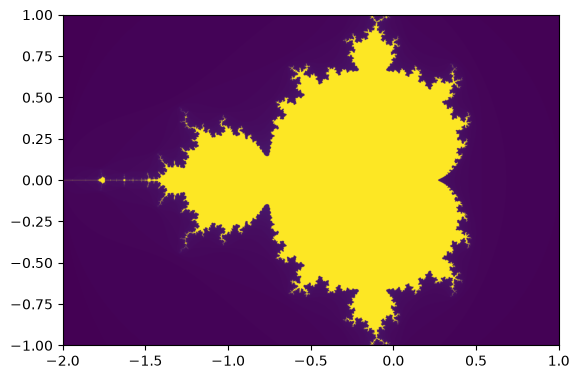

In [10]:
#from __future__ import print_function, division, absolute_import
image = np.zeros((2000, 3000), dtype=np.uint8)

with Timer() as t:
    mandelbrot = create_fractal(-2.0, 1.0, -1.0, 1.0, image, 20)

print("Time to create fractal: {0}".format(t.interval))
imshow(mandelbrot, extent=[-2, 1, -1, 1])
show()

In [11]:
@njit
def mandel(x, y, max_iters):
    """
    Given the real and imaginary parts of a complex number,
    determine if it is a candidate for membership in the Mandelbrot
    set given a fixed number of iterations.
    """

    i = 0
    c = complex(x,y)
    z = 0.0j

    for i in range(max_iters):
        z = z*z + c
        if (z.real*z.real + z.imag*z.imag) >= 4:
            return i

    return 255

In [12]:
@njit
def create_fractal(min_x, max_x, min_y, max_y, image, iters):

    height = image.shape[0]
    width = image.shape[1]
    pixel_size_x = (max_x - min_x) / width
    pixel_size_y = (max_y - min_y) / height

    for x in range(width):
        real = min_x + x * pixel_size_x
        for y in range(height):
            imag = min_y + y * pixel_size_y
            color = mandel(real, imag, iters)
            image[y, x] = color

    return image

Time to create fractal: 0.5369319915771484


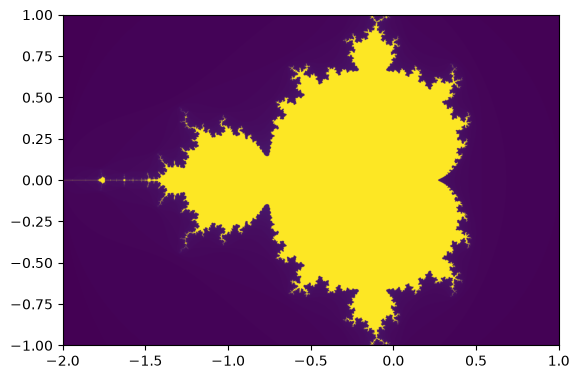

In [13]:
image = np.zeros((2000, 3000), dtype=np.uint8)

with Timer() as t:
    mandelbrot = create_fractal(-2.0, 1.0, -1.0, 1.0, image, 20)

print("Time to create fractal: {0}".format(t.interval))
imshow(mandelbrot, extent=[-2, 1, -1, 1])
show()

In [ ]:
@njit
# 在这parallel=True不适合，因为涉及到迭代，不能让多个线程分别计算
def mandel(x, y, max_iters):
    """
    Given the real and imaginary parts of a complex number,
    determine if it is a candidate for membership in the Mandelbrot
    set given a fixed number of iterations.
    """

    i = 0
    c = complex(x,y)
    z = 0.0j

    for i in range(max_iters):
        z = z*z + c
        if (z.real*z.real + z.imag*z.imag) >= 4:
            return i

    return 255

In [15]:
@njit(['uint8[:,:](float64, float64, float64, float64, uint8[:, :], uint8)'], parallel=True)
# uint8[:,:](float64, float64, float64, float64, uint8[:, :], uint8) 表示返回一个二维的uint8数组，
# 参数分别是四个float64类型的数，一个二维的uint8数组和一个uint8类型的数
def create_fractal(min_x, max_x, min_y, max_y, image, iters):

    height = image.shape[0]
    width = image.shape[1]
    pixel_size_x = (max_x - min_x) / width
    pixel_size_y = (max_y - min_y) / height
    # prange = parallel range, allows for parallel execution of the loop
    # 如何分配是由prange自己决定的，prange会根据CPU核心数和循环迭代次数来决定如何分配任务
    for x in prange(width):
        real = min_x + x * pixel_size_x
        for y in range(height):
            imag = min_y + y * pixel_size_y
            color = mandel(real, imag, iters)
            image[y, x] = color

    return image

In [16]:
# 原来
# CPU Core 1: 0 1 2 3 ...
# 现在
# prange
# Core 1 → x = 0 ... 749
# Core 2 → x = 750 ... 1499
# Core 3 → x = 1500 ... 2249
# Core 4 → x = 2250 ... 2999

In [17]:
# 为什么只给最外层上prange

# x loop
#     ↓
# y loop

# 每个线程负责若干列，每个x对应一整列

#         x →
#    ┌────────────────────┐
#  y │ Core1 │ Core2 │Core3│
#  ↓ │       │       │     │
#    │       │       │     │
#    │       │       │     │
#    └────────────────────┘

Time to create fractal: 0.025996923446655273


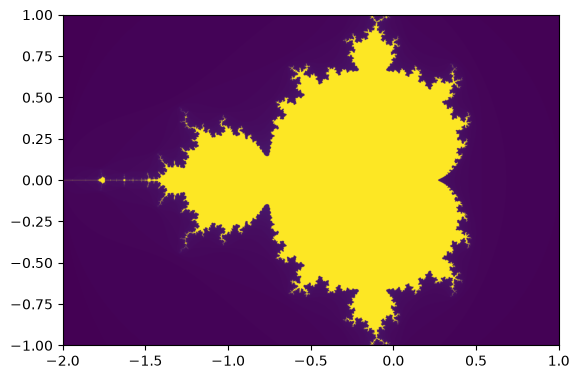

In [18]:
with Timer() as t:
    mandelbrot = create_fractal(-2.0, 1.0, -1.0, 1.0, image, 20)
print("Time to create fractal: {0}".format(t.interval))
imshow(mandelbrot, extent=[-2, 1, -1, 1])
show()

interactive(children=(FloatSlider(value=0.0, description='x', max=2.0, min=-2.0, step=0.001), FloatSlider(valu…

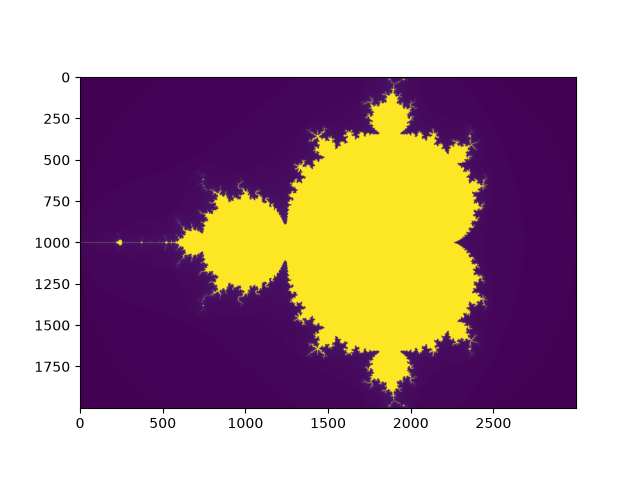

In [19]:
%matplotlib widget
fig, ax = subplots()
image = np.zeros((2000, 3000), dtype=np.uint8)
im = ax.imshow(image)
@interact(x=(-2,2,0.001),y=(-2,2,0.001),zoom=(0.0001, 2,0.0001), niters=(5,80))
def update(x=0,y=0,zoom=1.0, niters=27):
    image[...] = 0.0
    mandelbrot = create_fractal(-2.0*zoom + x, 1.0*zoom + x, -1.0*zoom + y, 1*zoom + y, image, niters)
    im.set_data(mandelbrot)
    im.set_clim(0,255)

In [ ]:
# 在大量的assembly code里搜索某个关键词

def find_instr(func, keyword, sig=0, limit=5):    
    count = 0    
    for l in func.inspect_asm(func.signatures[sig]).split('\n'):        
        if keyword in l:            
            count += 1            
            print(l)            
            if count >= limit:                
                break
    if count == 0:        
        print('No instructions found')

In [23]:
@jit(nopython=True)
def sqdiff(x, y):    
    out = np.empty_like(x)    
    for i in range(x.shape[0]):        
        out[i] = (x[i] - y[i])**2    
    return out

In [24]:
x32 = np.linspace(1, 2, 10000, dtype=np.float32)
y32  = np.linspace(2, 3, 10000, dtype=np.float32)
sqdiff(x32, y32)

array([1.        , 0.99999976, 1.        , ..., 1.        , 1.0000002 ,
       1.        ], shape=(10000,), dtype=float32)

In [25]:
x64 = x32.astype(np.float64)
y64 = y32.astype(np.float64)
sqdiff(x64, y64)

array([1.        , 0.99999976, 1.        , ..., 1.        , 1.00000024,
       1.        ], shape=(10000,))

In [26]:
sqdiff.signatures

[(Array(float32, 1, 'C', False, aligned=True),
  Array(float32, 1, 'C', False, aligned=True)),
 (Array(float64, 1, 'C', False, aligned=True),
  Array(float64, 1, 'C', False, aligned=True))]

In [27]:
%timeit sqdiff(x32, y32)
%timeit sqdiff(x64, y64)

3.33 μs ± 26.9 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
5.05 μs ± 12.2 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [28]:
print('float32:')
find_instr(sqdiff, keyword='subp', sig=0)
print('---\nfloat64:')
find_instr(sqdiff, keyword='subp', sig=1)

float32:
	vsubps	(%rax,%r9,4), %ymm0, %ymm0
	vsubps	32(%rax,%r9,4), %ymm1, %ymm1
	vsubps	64(%rax,%r9,4), %ymm2, %ymm2
	vsubps	96(%rax,%r9,4), %ymm3, %ymm3
	vsubps	(%rax,%r9,4), %xmm0, %xmm0
---
float64:
	vsubpd	(%rax,%r9,8), %ymm0, %ymm0
	vsubpd	32(%rax,%r9,8), %ymm1, %ymm1
	vsubpd	64(%rax,%r9,8), %ymm2, %ymm2
	vsubpd	96(%rax,%r9,8), %ymm3, %ymm3
	vsubpd	(%rax,%r9,8), %ymm0, %ymm0


In [ ]:
@jit(nopython=True)
def branching_code(x, y):
    out = np.empty_like(x)    
    for i in range(x.shape[0]):
        # 如果循环里有判断无法使用SIMD优化，虽然在数学上平方后结果是一样的
        if i % 100 == 0:            
            out[i] =  out[i] = (x[i] - y[i])**2        
        else:            
            out[i] =  out[i] = (y[i] - x[i])**2
    return out

In [32]:
branching_code(x32, y32)
find_instr(branching_code, keyword='subp', sig=0)

No instructions found


In [ ]:
# prange是把不同的循环迭代分配给不同的线程去执行，prange是一个并行的range函数
# SIMD是把同一条指令同时应用到多个数据上

In [33]:
@jit(nopython=True)
def frac_diff1(x, y):    
    out = np.empty_like(x)
    for i in range(x.shape[0]):
        out[i] = 2 * (x[i] - y[i]) / (x[i] + y[i])
    return out

In [34]:
frac_diff1(x32, y32)

array([-0.6666667 , -0.66662216, -0.66657776, ..., -0.400032  ,
       -0.40001604, -0.4       ], shape=(10000,), dtype=float32)

In [38]:
%timeit frac_diff1(x32, y32)

22 μs ± 175 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [36]:
find_instr(frac_diff1, keyword='subp', sig=0)

No instructions found


In [41]:
# numba采用python的除零语义，运算前需要判断分母是不是0，采用了if else结构，在除法中branch又出现了

In [ ]:
# 更改error_model = 'numpy',numpy在处理分母为0是输出inf或者NaN

@jit(nopython=True, error_model ='numpy')
def frac_diff2(x, y):
    out = np.empty_like(x)

    for i in range(x.shape[0]):
        out[i] = 2 * (x[i] - y[i]) / (x[i] + y[i])
    
    return out

In [45]:
frac_diff2(x32, y32)

array([-0.6666667 , -0.66662216, -0.66657776, ..., -0.400032  ,
       -0.40001604, -0.4       ], shape=(10000,), dtype=float32)

In [46]:
find_instr(frac_diff2, keyword='subp', sig=0)

	vsubps	%ymm1, %ymm0, %ymm2


In [76]:
%timeit frac_diff1(x32, y32)
%timeit frac_diff2(x32, y32)
%timeit frac_diff2(x64, y64)

21.8 μs ± 240 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
11.4 μs ± 29.5 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
11.3 μs ± 30.8 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [48]:
frac_diff2.inspect_types(pretty=True)

f:\conda-envs\sds2025\Lib\site-packages\numba\core\annotations\pretty_annotate.py:7: FutureWarning: The pretty_annotate functionality is experimental and might change API
  warn("The pretty_annotate functionality is experimental and might change API",


label 0
"x = arg(0, name=x) :: array(float32, 1d, C)"
"y = arg(1, name=y) :: array(float32, 1d, C)"
"3: def frac_diff2(x, y):"
$4load_global.0 = global(np: <module 'numpy' from 'f:\\conda-envs\\sds2025\\Lib\\site-packages\\numpy\\__init__.py'>) :: Module(<module 'numpy' from 'f:\\conda-envs\\sds2025\\Lib\\site-packages\\numpy\\__init__.py'>)
"$16load_method.2 = getattr(value=$4load_global.0, attr=empty_like) :: Function(<built-in function empty_like>)"
del $4load_global.0
"out = call $16load_method.2(x, func=$16load_method.2, args=[Var(x, 528195504.py:2)], kws=(), vararg=None, varkwarg=None, target=None) :: (Array(float32, 1, 'C', False, aligned=True), omitted(default=None)) -> array(float32, 1d, C)"
del $16load_method.2
5:
$56load_global.5 = global(range: <class 'range'>) :: Function(<class 'range'>)


In [ ]:
# 在该除法运算中float32相较float64性能提升不大，因为2*float32后提升为float64

In [51]:
# 强制常数2使用输入dtype

@jit(nopython=True, error_model='numpy')
def frac_diff3(x, y):
    out = np.empty_like(x)

    dt = x.dtype

    for i in range(x.shape[0]):
        # 把2转换成和输入数组一样的数据类型
        out[i] = dt.type(2) * (x[i] - y[i]) / (x[i] + y[i])

    return out

In [52]:
frac_diff3(x32, y32)

array([-0.6666667 , -0.66662216, -0.66657776, ..., -0.400032  ,
       -0.40001604, -0.4       ], shape=(10000,), dtype=float32)

In [53]:
%timeit frac_diff3(x32, y32)
%timeit frac_diff3(x64, y64)

4.72 μs ± 30.6 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
11.5 μs ± 63.7 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [54]:
# 也可以使用np.float32(2)强制输入类型，但dt.type(2)更灵活

In [ ]:
# 版本1
# @jit(nopython=True)

# division
# ↓
# Numba需要保持Python除零异常
# ↓
# 隐含 if denominator == 0
# ↓
# branch
# ↓
# autovectorizer 放弃
# ↓
# No SIMD
# ↓
# ≈ 27 μs

# 版本2
# error_model='numpy'

# 不需要Python式 ZeroDivisionError 检查
# ↓
# branch障碍消失
# ↓
# SIMD成功
# ↓
# ≈ 11 μs

# 版本3
# dt.type(2)

# 常数和输入保持相同dtype
# ↓
# 整个计算保持float32
# ↓
# SIMD register一次处理更多元素
# ↓
# ≈ 5 μs

In [55]:
# SIMD还可以加速reduction操作，比如sum、mean、max、min等
@jit(nopython=True)
def do_sum(A):
    acc = 0.
    for i in range(A.size):
        acc += A[i]**2
    return acc

In [ ]:
@jit(nopython=True, fastmath=True)
def do_sum_fast(A):
    acc = 0.
    for i in range(A.size):
        acc += A[i]**2
    return acc

# 普通版本
# ↓
# 必须保持严格浮点运算顺序
# ↓
# 难以 vectorize

# fastmath=True
# ↓
# 允许 reassociation / reordering
# ↓
# reduction 可-以 SIMD
# ↓
# 明显加速

In [57]:
# NumExpr = 把一个 NumPy 风格的逐元素表达式交给它，它会用更高效的方式执行，通常还会自动多线程。

In [ ]:
# elemwntwise是NumExpr主要处理的类型，点乘等涉及到行列变换的操作，NumExpr不适合处理

In [ ]:
# NumExpr 也能处理很多像 sin()、exp() 这样的数学函数，这样的数学函数叫transcendental functions，
# NumExpr会把这些函数的计算拆分成更简单的操作，然后用SIMD加速

In [ ]:
a = np.random.rand(1000000)
b = np.random.rand(1000000)

print(ne.evaluate("a + 1"))
print(ne.evaluate('a + b'))
# NumExpr用字符串想先看到整个表达式进行整体分析

[1.86841336 1.32176045 1.2957999  ... 1.5578266  1.52415546 1.72507192]
[1.46196403 0.56684067 0.70037181 ... 0.68164912 1.51771164 0.80545014]


In [66]:
ne.evaluate('a*b-4.1*a > 2.5*b')

array([False, False, False, ..., False, False, False], shape=(1000000,))

In [69]:
%%timeit 
a * b - 4.1 * a > 2.5 * b

14.3 ms ± 143 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [74]:
%%timeit
np.sin(a) + np.arcsinh(a / b)

39.5 ms ± 357 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [75]:
%%timeit
ne.evaluate("sin(a) + arcsinh(a/b)")

5.27 ms ± 48.7 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
# NumPy
# ↓
# 基础高效数组运算

# NumExpr
# ↓
# 轻量加速复杂逐元素表达式

# Numba
# ↓
# JIT编译自定义数值循环/函数
# ↓
# 还能进一步用
# prange / SIMD / fastmath